<a href="https://colab.research.google.com/github/Anshikasharma37/student-dropout-StrangerStrings/blob/dev/dataLoading_stats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (4424, 39)

First few rows:
  Marital Status                  Application Mode  Application Order  \
0         Single      2nd phase—general contingent           1.000000   
1         Single  International student (bachelor)           0.285714   
2         Single      1st phase—general contingent           1.000000   
3         Single      2nd phase—general contingent           0.571429   
4        Married                 Over 23 years old           0.285714   

                           Course Name Daytime/Evening Attendance  \
0      Animation and Multimedia Design                    Daytime   
1                              Tourism                    Daytime   
2                 Communication Design                    Daytime   
3         Journalism and Communication                    Daytime   
4  Social Service (evening attendance)                    Evening   

  Previous Qualification Nationality            Mother's Qualification  \
0    Secondary education  Por

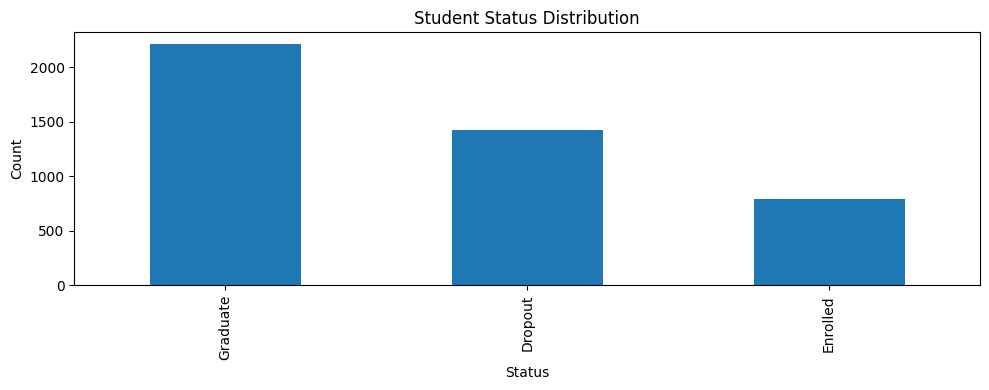


=== MISSING VALUES ===
Series([], dtype: int64)
No missing values to display.

=== DATA TYPES ===
Marital Status                    object
Application Mode                  object
Application Order                float64
Course Name                       object
Daytime/Evening Attendance        object
Previous Qualification            object
Nationality                       object
Mother's Qualification            object
Father's Qualification            object
Mother's Occupation               object
Father's Occupation               object
Displaced Student                 object
Special Educational Needs         object
Is Debtor                         object
Tuition Fees Up-to-Date           object
Gender (1=Male, 0=Female)         object
Scholarship Holder                object
Age at Enrollment                float64
International Student             object
Credited Units (1st Sem)         float64
Enrolled Units (1st Sem)         float64
Evaluated Units (1st Sem)        float64

<Figure size 1200x400 with 0 Axes>

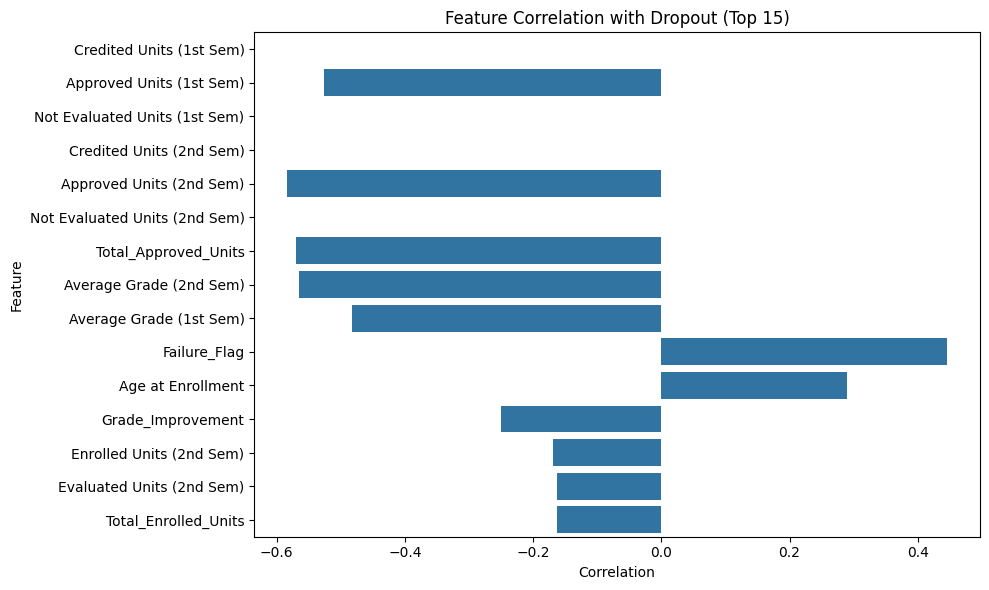


=== CORRELATION HEATMAP ===


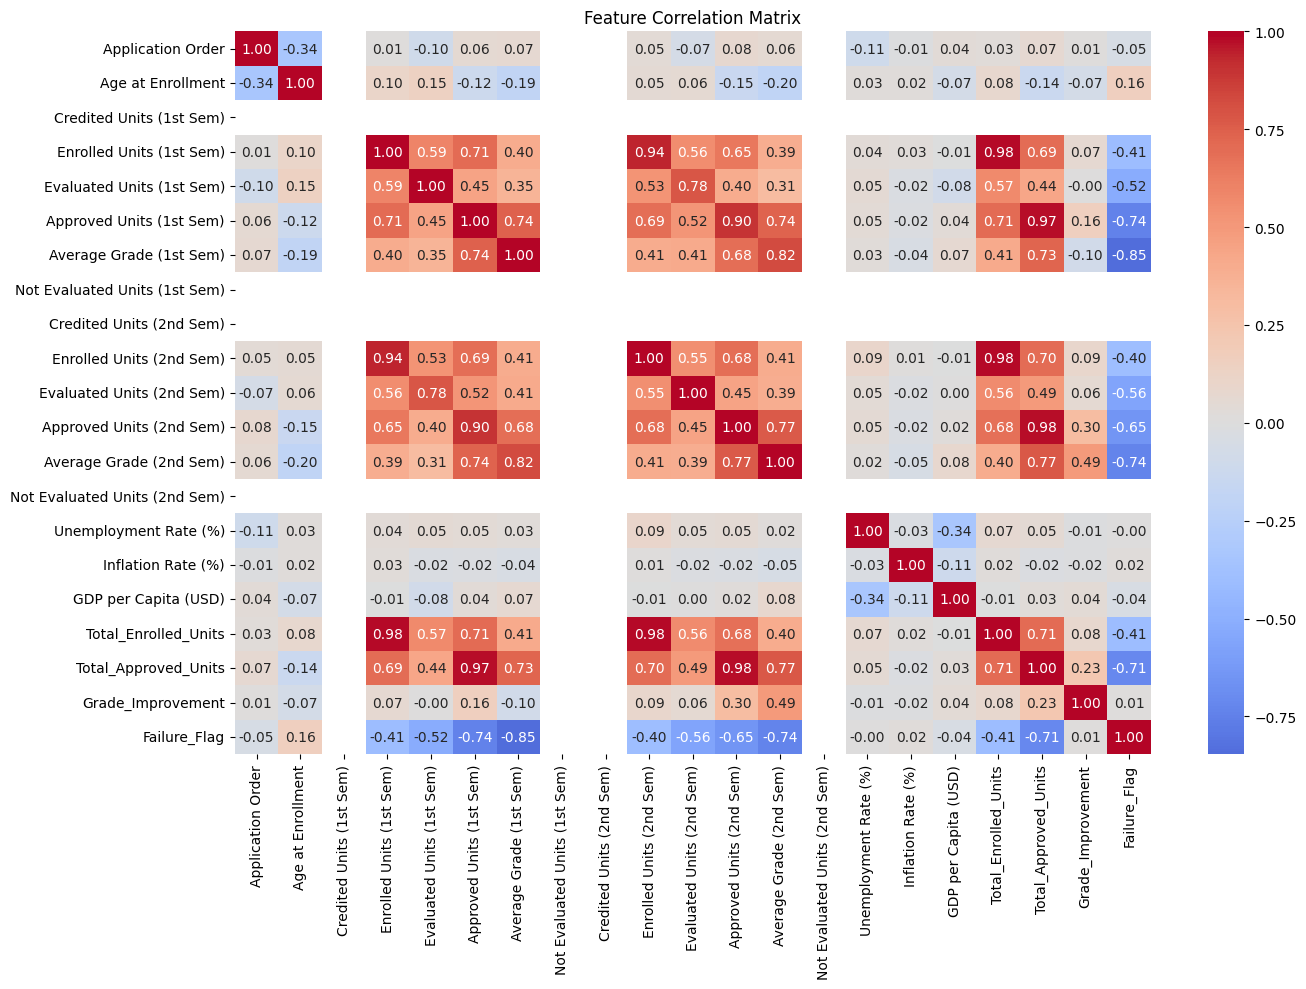


=== OUTLIER DETECTION ===
Age at Enrollment: 501 outliers (11.32%) errors_to_fix
Average Grade (1st Sem): 0 outliers (0.00%) errors_to_fix
Unemployment Rate (%): 0 outliers (0.00%) errors_to_fix


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind
import warnings
warnings.filterwarnings('ignore')

# ==================== DATA LOADING ====================


df_nit = pd.read_csv('normalized_dataset.csv')
print("Dataset shape:", df_nit.shape)
print("\nFirst few rows:")
print(df_nit.head())

# ==================== BASIC EXPLORATION ====================

# 1. Target Distribution
print("\n=== TARGET VARIABLE DISTRIBUTION ===")
print(df_nit['Student Status'].value_counts())
print(df_nit['Student Status'].value_counts(normalize=True) * 100)

# Visualize
plt.figure(figsize=(10, 4))
df_nit['Student Status'].value_counts().plot(kind='bar')
plt.title('Student Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 2. Missing Values
print("\n=== MISSING VALUES ===")
missing_data = df_nit.isnull().sum()
print(missing_data[missing_data > 0])

# Visualize missing data
plt.figure(figsize=(12, 4))
missing_percent = (df_nit.isnull().sum() / len(df_nit)) * 100
# Only plot if there are missing values to avoid IndexError
if not missing_percent[missing_percent > 0].empty:
    missing_percent[missing_percent > 0].plot(kind='barh')
    plt.xlabel('Percentage Missing')
    plt.title('Missing Data by Column')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values to display.")

# 3. Data Types
print("\n=== DATA TYPES ===")
print(df_nit.dtypes)

# 4. Descriptive Statistics
print("\n=== DESCRIPTIVE STATISTICS ===")
print(df_nit.describe())

# ==================== FEATURE ANALYSIS ====================

# Identify numerical and categorical columns
numerical_cols = df_nit.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_nit.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumerical columns ({len(numerical_cols)}): {numerical_cols[:5]}...")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols[:5]}...")

# ==================== DROPOUT ANALYSIS ====================

# Compare features by dropout status
print("\n=== DROPOUT RATE BY KEY FEATURES ===")

# Academic Performance
for threshold in [6.0, 7.0, 8.0]:
    high_cgpa = df_nit[df_nit['Age at Enrollment'] < 20]  # Example with age
    if len(high_cgpa) > 0:
        dropout_rate = (high_cgpa['Student Status'] == 'Dropout').sum() / len(high_cgpa) * 100
        print(f"Age < 20: Dropout rate = {dropout_rate:.2f}%")

# ==================== CORRELATION ANALYSIS ====================

print("\n=== FEATURE CORRELATION WITH DROPOUT ===")

# Create binary target (1 = Dropout, 0 = Not Dropout)
target_binary = (df_nit['Student Status'] == 'Dropout').astype(int)

# Calculate correlation for numerical features
correlations = {}
for col in numerical_cols:
    if col in df_nit.columns and df_nit[col].dtype in [np.float64, np.int64]:
        try:
            corr = df_nit[col].corr(target_binary)
            correlations[col] = corr
        except:
            pass

# Sort and display
sorted_corr = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True) # Fixed the key to sort by absolute correlation value
print("\nTop 10 correlated features:")
for feature, corr in sorted_corr[:10]:
    print(f"{feature}: {corr:.4f}")

# Visualize
corr_df = pd.DataFrame(list(sorted_corr[:15]), columns=['Feature', 'Correlation'])
plt.figure(figsize=(10, 6))
sns.barplot(data=corr_df, x='Correlation', y='Feature')
plt.title('Feature Correlation with Dropout (Top 15)')
plt.tight_layout()
plt.show()

# ==================== HEATMAP ====================

print("\n=== CORRELATION HEATMAP ===")

# Select numerical columns
numerical_subset = df_nit[numerical_cols].select_dtypes(include=[np.number])

# Create correlation matrix
corr_matrix = numerical_subset.corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# ==================== OUTLIER DETECTION ====================

print("\n=== OUTLIER DETECTION ===")

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return outliers

# Check for outliers in key features
key_features = ['Age at Enrollment', 'Average Grade (1st Sem)', 'Unemployment Rate (%)']
for feature in key_features:
    if feature in df_nit.columns:
        outliers = detect_outliers_iqr(df_nit, feature)
        print(f"{feature}: {len(outliers)} outliers ({len(outliers)/len(df_nit)*100:.2f}%) errors_to_fix")

# New Section